## Problem Statement

This project aims to forecast PM2.5 air pollution levels using time series machine learning models. By leveraging historical air quality and meteorological data, the study evaluates statistical and machine learning approaches to identify the most accurate method for predicting air pollution trends and supporting environmental decision-making.

## Loading and Exploring Data

In [12]:
import pandas as pd
import numpy as np
from scipy.io import arff
import arff
import seaborn as sns
import matplotlib.pyplot as plt

#the main lib here is the statmodel
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA


In [13]:
with open(r'C:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING\dataset.arff', 'r') as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset['data'], 
                  columns=[attr[0] for attr in dataset['attributes']])

In [14]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


### Data Pre-processing

In [16]:
# Handling missing values
df.isnull().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

In [17]:
# handle erroneus reading
df.replace(-200, pd.NA, inplace=True)


In [18]:
# converting to datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [19]:
# set as index
df.set_index('datetime', inplace=True)

In [20]:
# sort index
df.sort_index(inplace=True)
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [21]:
# filling missing values
df.interpolate(method='time', inplace=True)
df.fillna(method='bfill', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13740\3500138193.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='time', inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13740\3500138193.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


Aggregate variables

In [22]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

daily_df = df.resample('D').agg({
    **{col: 'mean' for col in num_cols},
    **{col: (lambda x: x.mode()[0] if not x.mode().empty else None) for col in cat_cols}
})

### Train Test Split

In [23]:
split = int(len(daily_df) * 0.8)

train = daily_df.iloc[:split]
test = daily_df.iloc[split:]
print(train.shape)
print(test.shape)

(1168, 18)
(293, 18)


In [24]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2013-03-01 00:00:00 2016-05-11 00:00:00
2016-05-12 00:00:00 2017-02-28 00:00:00


Visualization

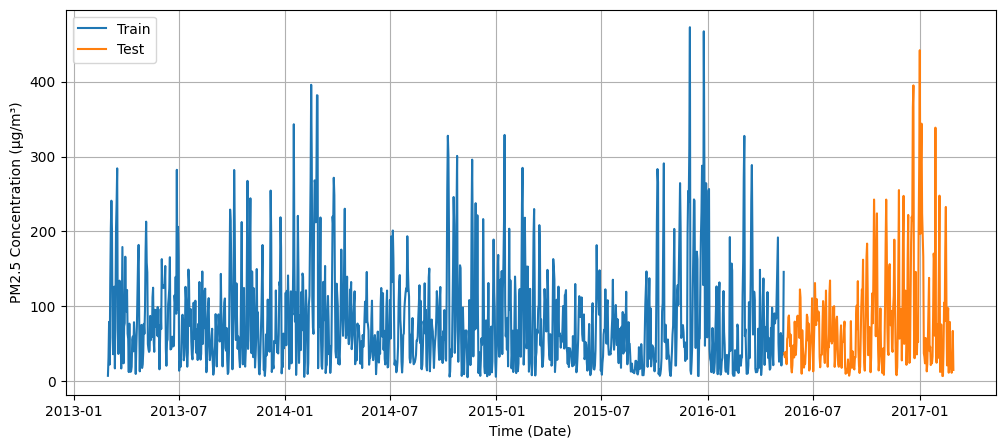

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.grid(True)
plt.xlabel('Time (Date)')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.plot(train['PM2.5'], label='Train')
plt.plot(test['PM2.5'], label='Test')
plt.legend()
plt.show()

The time series plot illustrates a clear chronological split between training and testing datasets, ensuring no data leakage. The pollutant levels exhibit high variability with frequent extreme spikes, indicating the dynamic nature of air quality.
The presence of noise and volatility highlights the need for feature engineering techniques to improve model performance

#### Feature Engineering

In [26]:
# Lag features
daily_df['lag_1'] = daily_df['PM2.5'].shift(1)
daily_df['lag_7'] = daily_df['PM2.5'].shift(7)
daily_df['lag_14'] = daily_df['PM2.5'].shift(14)

In [27]:
# moving average
daily_df['rolling_mean_7'] = daily_df['PM2.5'].rolling(7).mean()
daily_df['rolling_mean_14'] = daily_df['PM2.5'].rolling(14).mean()
daily_df['rolling_std_7'] = daily_df['PM2.5'].rolling(7).std()

In [28]:
# time based features(day of week, month, year)
daily_df['day_of_week'] = daily_df.index.dayofweek
daily_df['month'] = daily_df.index.month
daily_df['day_of_year'] = daily_df.index.dayofyear

In [29]:
# external factors
daily_df['is_weekend'] = (daily_df.index.dayofweek >= 5).astype(int)

In [30]:
# handle nans
daily_df.dropna(inplace=True)

### Model Selection and Training

In [33]:
# ARIMA model
model_arima = ARIMA(train['PM2.5'], order=(5,1,0))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1168
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6382.941
Date:                Tue, 21 Apr 2026   AIC                          12777.881
Time:                        23:37:14   BIC                          12808.255
Sample:                    03-01-2013   HQIC                         12789.339
                         - 05-11-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1864      0.022     -8.500      0.000      -0.229      -0.143
ar.L2         -0.3641      0.022    -16.414      0.000      -0.408      -0.321
ar.L3         -0.2452      0.026     -9.563      0.0

In [39]:
pred_arima = model_arima_fit.forecast(steps=len(test))
print(pred_arima)

2016-05-12    126.105324
2016-05-13     92.049108
2016-05-14     80.744544
2016-05-15     77.348079
2016-05-16     85.753188
                 ...    
2017-02-24     91.348048
2017-02-25     91.348048
2017-02-26     91.348048
2017-02-27     91.348048
2017-02-28     91.348048
Freq: D, Name: predicted_mean, Length: 293, dtype: float64


In [35]:
# Model 2: SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_sarima = SARIMAX(train['PM2.5'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING\advanced\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                              PM2.5   No. Observations:                 1168
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -6305.062
Date:                            Tue, 21 Apr 2026   AIC                          12620.124
Time:                                    23:41:09   BIC                          12645.384
Sample:                                03-01-2013   HQIC                         12629.657
                                     - 05-11-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5711      0.014     40.020      0.000       0.543       0.599
ma.L1         -0.9995      0.036   

In [40]:
pred_sarima = model_sarima_fit.forecast(steps=len(test))
print(pred_sarima)

2016-05-12    112.602766
2016-05-13     97.583099
2016-05-14     97.189875
2016-05-15     87.922117
2016-05-16     75.436623
                 ...    
2017-02-24     69.232756
2017-02-25     73.319679
2017-02-26     79.790885
2017-02-27     76.009386
2017-02-28     67.334066
Freq: D, Name: predicted_mean, Length: 293, dtype: float64


### Auto_Arima

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=14177.984, Time=1.72 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=12865.479, Time=0.41 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=13359.087, Time=0.49 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=12866.540, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=12865.689, Time=0.19 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=12856.492, Time=0.65 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=12654.387, Time=1.27 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=12818.313, Time=0.34 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=2.25 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=1.74 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=12647.840, Time=0.51 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=12645.842, Time=1.52 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=12644.580, Time=0.93 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=12694.073, Time=1.54 sec
 ARIMA(1,0,0)(0,0,0)[0] interce

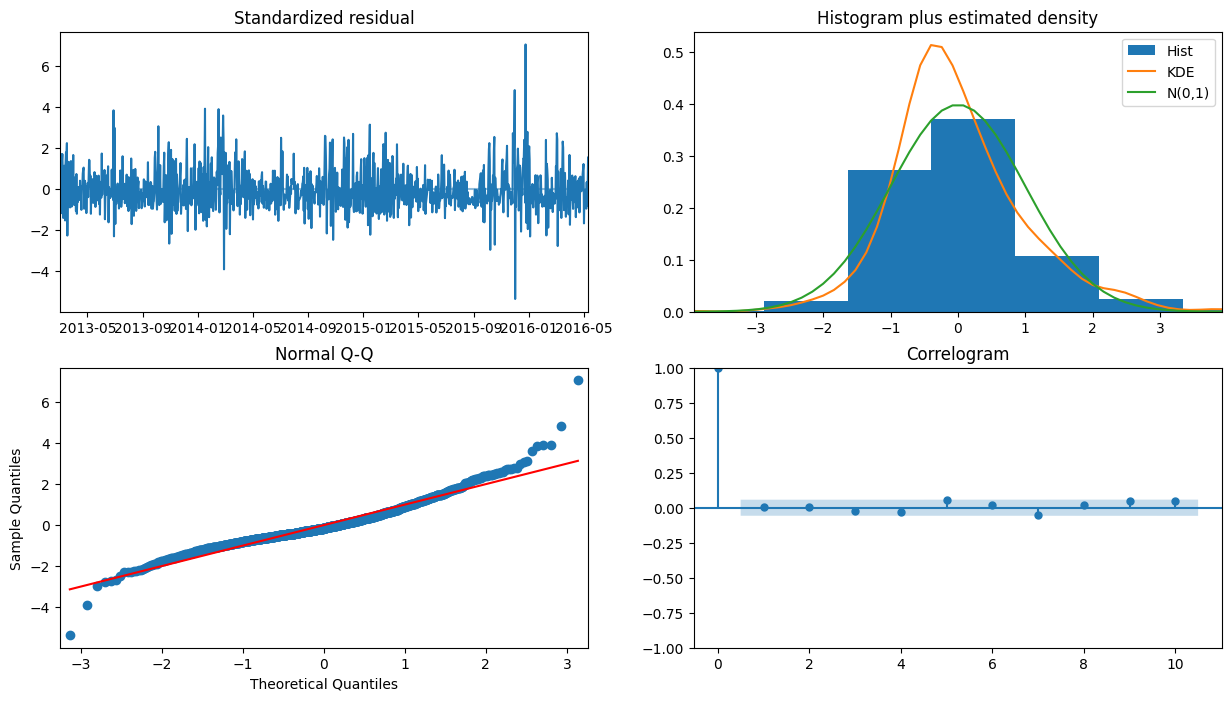

In [37]:
from pmdarima.arima import auto_arima
model_autoARIMA = auto_arima(
    train['PM2.5'],   # ✅ only target variable
    start_p=0, start_q=0,
    test='adf',
    max_p=3, max_q=3,
    m=1,
    d=None,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

### Model Evaluation

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return rmse, mae

rmse_arima, mae_arima = evaluate(test['PM2.5'], pred_arima)
rmse_sarima, mae_sarima = evaluate(test['PM2.5'], pred_sarima)

print("ARIMA:", rmse_arima, mae_arima)
print("SARIMA:", rmse_sarima, mae_sarima)


ARIMA: 71.30192237726386 54.541969787299415
SARIMA: 70.97703954071734 49.74726075032236


### Visualization

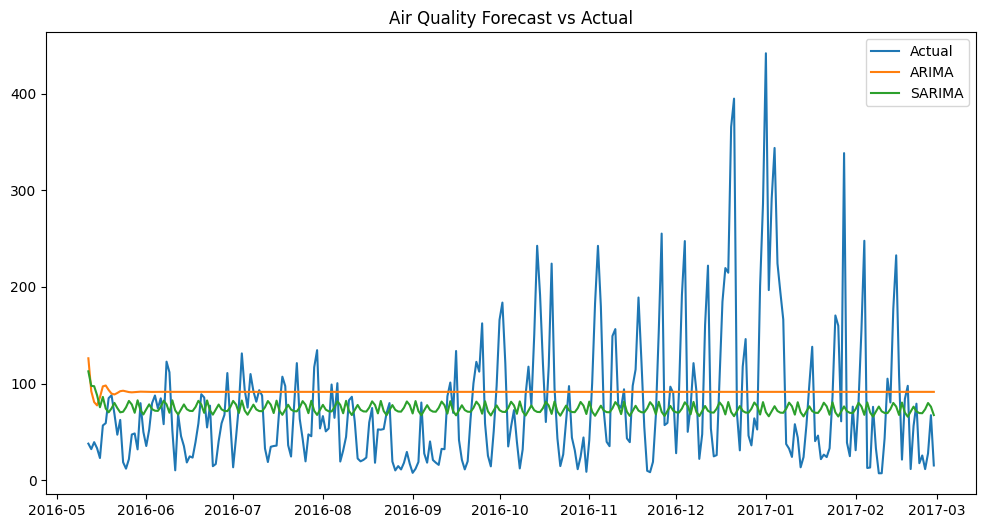

In [42]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test['PM2.5'], label='Actual')
plt.plot(test.index, pred_arima, label='ARIMA')
plt.plot(test.index, pred_sarima, label='SARIMA')

plt.legend()
plt.title("Air Quality Forecast vs Actual")
plt.show()

The comparison between actual and predicted values shows that both ARIMA and SARIMA models struggle to capture the high variability and extreme spikes in PM2.5 concentrations. The ARIMA model produces nearly constant predictions, indicating underfitting, while the SARIMA model captures slight temporal fluctuations but still fails to model sudden changes effectively